# Physarum Polycephalum Simulation

This project simulates the behavior of a slime mold. It uses a particle-based approach where thousands of agents move independently but interact through a shared environment (trail map).

**The Rules of the Agents:**
1.  **Movement:** Agents move forward with a specific speed and angle.
2.  **Sensing:** Agents have three sensors (front-left, front, front-right) to detect the chemical trail left by others.
3.  **Turning:** Agents turn towards the strongest trail concentration.
4.  **Deposit:** Agents leave a trail on the map as they move.
5.  **Decay:** The trail map slowly fades over time, removing old paths.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Simulation Parameters
WIDTH = 400
HEIGHT = 400
NUM_AGENTS = 5000
SENSOR_ANGLE = np.pi / 4  # 45 degrees
TURN_ANGLE = np.pi / 4    # 45 degrees
SENSOR_DIST = 9
DECAY_RATE = 0.95         # How fast the trail fades (0-1)
DIFFUSION_RATE = 0.20     # Fraction mixed with the four-neighbour average

# Initialize global random seed
rng = np.random.default_rng(42)

print(f"Simulation configured with {NUM_AGENTS} agents on a {WIDTH}x{HEIGHT} grid.")

Simulation configured with 5000 agents on a 400x400 grid.


## Step 2: Initialize Agents

We create the data structures for the agents. Instead of Python objects, we use NumPy arrays for performance.
* **x, y:** The coordinates of each agent.
* **angle:** The direction each agent is facing (in radians).

We initialize all agents at the center of the map with random directions.

In [2]:
# Random positions concentrated in the center (circle distribution)
# This creates an "explosion" effect at the start
radius = 100
random_r = np.sqrt(rng.random(NUM_AGENTS)) * radius
random_theta = rng.random(NUM_AGENTS) * 2 * np.pi

agents_x = (WIDTH / 2) + random_r * np.cos(random_theta)
agents_y = (HEIGHT / 2) + random_r * np.sin(random_theta)

# Random initial heading (0 to 2pi)
agents_angle = rng.random(NUM_AGENTS) * 2 * np.pi

# The Trail Map (The environment)
trail_map = np.zeros((HEIGHT, WIDTH))

print("Agents initialized.")

Agents initialized.


## Step 3: Sensing Logic

Agents need to sense the environment to make decisions.
1.  **Calculate Sensor Positions:** We determine the coordinates (x, y) of the Left, Center, and Right sensors based on the agent's current angle and `SENSOR_DIST`.
2.  **Sample Trail Map:** We read the values of the trail map at those sensor locations.
3.  **Steer:**
    * If **Center** is strongest -> Keep going straight.
    * If **Left** is strongest -> Turn Left.
    * If **Right** is strongest -> Turn Right.
    * If all are low -> Rotate randomly (Explore).

In [3]:
def run_step(trail_map, agents_x, agents_y, agents_angle):
    
    # --- 1. SENSING ---
    # Calculate sensor coordinates
    # Left Sensor
    sensor_left_x = agents_x + np.cos(agents_angle + SENSOR_ANGLE) * SENSOR_DIST
    sensor_left_y = agents_y + np.sin(agents_angle + SENSOR_ANGLE) * SENSOR_DIST
    
    # Center Sensor
    sensor_center_x = agents_x + np.cos(agents_angle) * SENSOR_DIST
    sensor_center_y = agents_y + np.sin(agents_angle) * SENSOR_DIST
    
    # Right Sensor
    sensor_right_x = agents_x + np.cos(agents_angle - SENSOR_ANGLE) * SENSOR_DIST
    sensor_right_y = agents_y + np.sin(agents_angle - SENSOR_ANGLE) * SENSOR_DIST
    
    # Helper to wrap coordinates around edges (Toroidal world)
    def get_trail_value(x, y):
        # Use the same periodic boundary as the movement rule.
        xi = np.floor(x).astype(int) % WIDTH
        yi = np.floor(y).astype(int) % HEIGHT
        return trail_map[yi, xi]

    v_left = get_trail_value(sensor_left_x, sensor_left_y)
    v_center = get_trail_value(sensor_center_x, sensor_center_y)
    v_right = get_trail_value(sensor_right_x, sensor_right_y)
    
    # --- 2. TURNING (Vectorized Logic) ---
    # Random steering factor
    random_steer = rng.random(NUM_AGENTS) * 0.2
    
    # Conditions
    # If Center > Left and Center > Right: Do nothing (continue straight)
    # If Left > Center and Left > Right: Turn Left (+)
    turn_left_mask = (v_left > v_center) & (v_left > v_right)
    agents_angle[turn_left_mask] += TURN_ANGLE * random_steer[turn_left_mask]
    
    # If Right > Center and Right > Left: Turn Right (-)
    turn_right_mask = (v_right > v_center) & (v_right > v_left)
    agents_angle[turn_right_mask] -= TURN_ANGLE * random_steer[turn_right_mask]

    # Explore when no sensor is strictly preferred or no trail is present.
    explore_mask = ~(turn_left_mask | turn_right_mask) & (v_center <= 0)
    agents_angle[explore_mask] += rng.uniform(-TURN_ANGLE, TURN_ANGLE, explore_mask.sum())
    
    # --- 3. MOVEMENT ---
    agents_x += np.cos(agents_angle)
    agents_y += np.sin(agents_angle)
    
    # Wrap around edges
    agents_x = agents_x % WIDTH
    agents_y = agents_y % HEIGHT
    
    # --- 4. DEPOSIT TRAIL ---
    # Add density to the current position
    xi = agents_x.astype(int)
    yi = agents_y.astype(int)
    np.add.at(trail_map, (yi, xi), 1)  # Accumulate every agent, including collisions.
    
    # Limit max value to avoid overflow
    np.clip(trail_map, 0, 255, out=trail_map)
    
    # --- 5. DIFFUSE AND DECAY ---
    neighbour_mean = (
        np.roll(trail_map, 1, axis=0) + np.roll(trail_map, -1, axis=0)
        + np.roll(trail_map, 1, axis=1) + np.roll(trail_map, -1, axis=1)
    ) / 4.0
    trail_map[:] = (1.0 - DIFFUSION_RATE) * trail_map + DIFFUSION_RATE * neighbour_mean
    trail_map *= DECAY_RATE
    
    return trail_map, agents_x, agents_y, agents_angle

print("Simulation logic defined.")

Simulation logic defined.


## Step 4: Run Simulation and Animate

We run the simulation loop for a set number of frames.
We use `matplotlib.animation` to render the evolution of the trail map.

In [4]:
import os
from PIL import Image as PILImage
from IPython.display import Image as IPyImage

# 1. Reset Simulation
trail_map = np.zeros((HEIGHT, WIDTH))
random_r = np.sqrt(rng.random(NUM_AGENTS)) * 100
random_theta = rng.random(NUM_AGENTS) * 2 * np.pi
agents_x = (WIDTH / 2) + random_r * np.cos(random_theta)
agents_y = (HEIGHT / 2) + random_r * np.sin(random_theta)
agents_angle = rng.random(NUM_AGENTS) * 2 * np.pi

# 2. Configuration for the "Director's Cut"
frames_total = 400       # Total frames to capture
steps_per_frame = 3      # Simulation steps between captures (Smoothness)
output_filename = "slime_mold_evolution.gif"

print(f"Starting render: {frames_total} frames. Saving directly to '{output_filename}'...")

# Pre-allocate list to store frames
saved_frames = []

# Matplotlib Colormap setup manually to apply to raw numpy array
# We normalize the trail map (0-1) to 0-255 grayscale or colormapped image
import matplotlib.cm as cm
cmap = plt.get_cmap('magma') # or 'inferno'

for i in range(frames_total):
    # Run simulation steps
    for _ in range(steps_per_frame):
        trail_map, agents_x, agents_y, agents_angle = run_step(trail_map, agents_x, agents_y, agents_angle)
    
    # Convert Numpy Array -> Image
    # 1. Normalize and Apply Colormap
    # trail_map is 0.0-1.0. cmap expects 0.0-1.0
    colored_map = cmap(np.clip(trail_map, 0, 1)) # Returns RGBA 0.0-1.0
    
    # 2. Convert to 0-255 uint8
    img_uint8 = (colored_map[:, :, :3] * 255).astype(np.uint8) # Drop Alpha channel
    
    # 3. Create PIL Image
    im = PILImage.fromarray(img_uint8)
        
    saved_frames.append(im)
    
    if i % 50 == 0:
        print(f"Captured frame {i}/{frames_total}")

print("Saving GIF file to disk...")

# Save the frames as a GIF
saved_frames[0].save(
    output_filename,
    save_all=True,
    append_images=saved_frames[1:],
    optimize=True,
    duration=40,  # 40ms per frame = 25 fps
    loop=0
)

print(f"Success! File saved: {os.path.getsize(output_filename) / (1024*1024):.2f} MB")

Starting render: 400 frames. Saving directly to 'slime_mold_evolution.gif'...
Captured frame 0/400


Captured frame 50/400


Captured frame 100/400


Captured frame 150/400


Captured frame 200/400


Captured frame 250/400


Captured frame 300/400


Captured frame 350/400


Saving GIF file to disk...


Success! File saved: 7.06 MB


## Step 5: Display (Base64 Injection)

If the standard image viewer fails to load the local file due to size or path restrictions, we use **Base64 encoding**.

This reads the binary data of the GIF, converts it into a text string, and injects it directly into the HTML of the notebook cell.

Injecting slime_mold_evolution.gif directly into the notebook DOM...



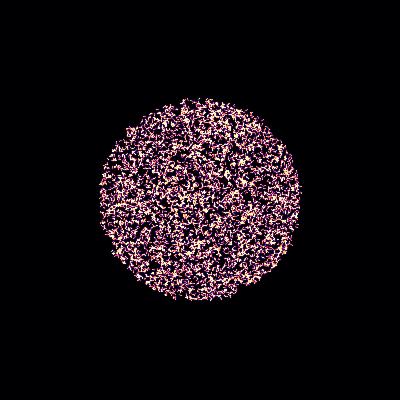

Visual confirmed.


In [5]:
import base64
from IPython.display import HTML

# Ensure the filename matches what we saved in the previous step
target_file = "slime_mold_evolution.gif"

print(f"Injecting {target_file} directly into the notebook DOM...")

try:
    with open(target_file, "rb") as image_file:
        # 1. Read binary and encode to base64 string
        encoded_string = base64.b64encode(image_file.read()).decode('ascii')
    
    # 2. Create an HTML tag with the raw data
    # We set width to 100% so it fits nicely in the cell
    html_tag = f'<img src="data:image/gif;base64,{encoded_string}" style="width:100%; max-width:800px; border: 2px solid #333;">'
    
    # 3. Render
    display(HTML(html_tag))
    print("Visual confirmed.")

except FileNotFoundError:
    print(f"Error: Could not find '{target_file}'. Make sure Step 4 finished successfully.")